In [21]:
from pathlib import Path

import rasterio
from rasterio.enums import Resampling

import numpy as np

import matplotlib.pyplot as plt

In [22]:
safe_2021 = Path(
    r"../data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE"
)

safe_2026 = Path(
    r"../data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE"
)

output_dir = Path("../data/processed")
output_dir.mkdir(exist_ok=True)

In [23]:
def find_band(
    safe_path,
    band_name
):

    img_dirs = list(
        safe_path.glob(
            "GRANULE/*/IMG_DATA/*"
        )
    )

    for img_dir in img_dirs:

        matches = list(
            img_dir.glob(
                f"*_{band_name}_*.jp2"
            )
        )

        if matches:

            return matches[0]

    raise FileNotFoundError(
        f"{band_name} not found"
    )

In [24]:
bands = [
    "B04",
    "B08",
    "B11"
]

paths_2021 = {}
paths_2026 = {}

for band in bands:

    paths_2021[band] = find_band(
        safe_2021,
        band
    )

    paths_2026[band] = find_band(
        safe_2026,
        band
    )

    print(
        band,
        "\n2021:",
        paths_2021[band],
        "\n2026:",
        paths_2026[band],
        "\n"
    )

B04 
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B04_10m.jp2 
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m\T43QHV_20260601T050649_B04_10m.jp2 

B08 
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B08_10m.jp2 
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m\T43QHV_20260601T050649_B08_10m.jp2 

B11 
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R20m\T43QHV_20210309T050649_B11_20m.jp2 
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_

In [25]:
def read_band(
    path
):

    with rasterio.open(path) as src:

        return src.read(1)

In [26]:
red_2021 = read_band(
    paths_2021["B04"]
)

nir_2021 = read_band(
    paths_2021["B08"]
)

red_2026 = read_band(
    paths_2026["B04"]
)

nir_2026 = read_band(
    paths_2026["B08"]
)

In [27]:
def read_swir_10m(
    path
):

    with rasterio.open(path) as src:

        swir = src.read(
            1,
            out_shape=(
                src.height * 2,
                src.width * 2
            ),
            resampling=Resampling.bilinear
        )

    return swir

In [28]:
swir_2021 = read_swir_10m(
    paths_2021["B11"]
)

swir_2026 = read_swir_10m(
    paths_2026["B11"]
)

print(
    "NIR:",
    nir_2021.shape
)

print(
    "SWIR:",
    swir_2021.shape
)

NIR: (10980, 10980)
SWIR: (10980, 10980)


In [29]:
def ndbi(
    swir,
    nir
):

    swir = swir.astype(
        np.float32
    )

    nir = nir.astype(
        np.float32
    )

    return (
        (swir - nir)
        /
        (swir + nir + 1e-6)
    )

In [30]:
ndbi_2021 = ndbi(
    swir_2021,
    nir_2021
)

ndbi_2026 = ndbi(
    swir_2026,
    nir_2026
)

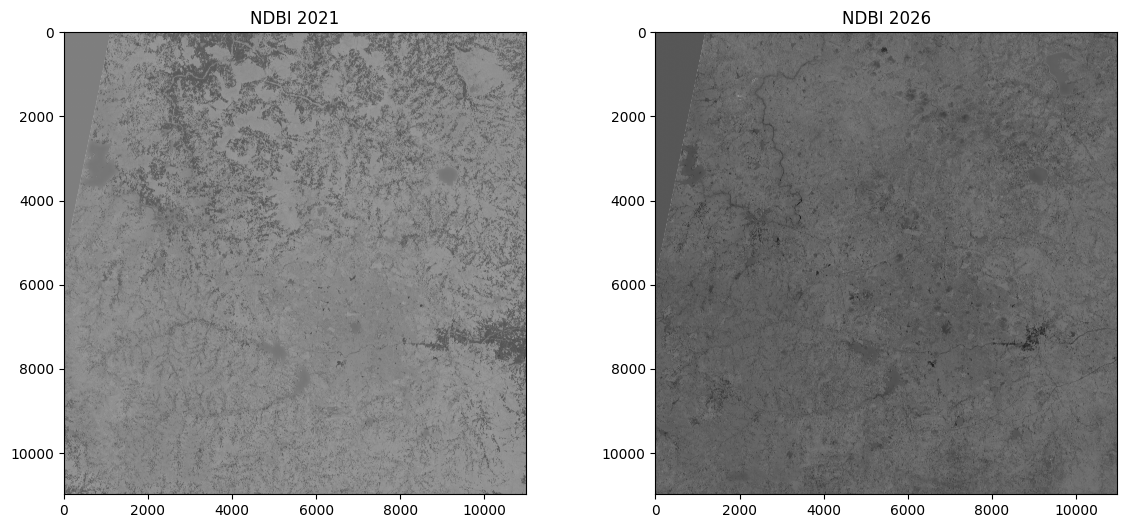

In [31]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

ax[0].imshow(
    ndbi_2021,
    cmap="gray"
)

ax[0].set_title(
    "NDBI 2021"
)

ax[1].imshow(
    ndbi_2026,
    cmap="gray"
)

ax[1].set_title(
    "NDBI 2026"
)

plt.show()

In [32]:
ndbi_change = (
    ndbi_2026
    -
    ndbi_2021
)

In [33]:
urban_growth_mask = (
    ndbi_change > 0.15
).astype(
    np.uint8
)

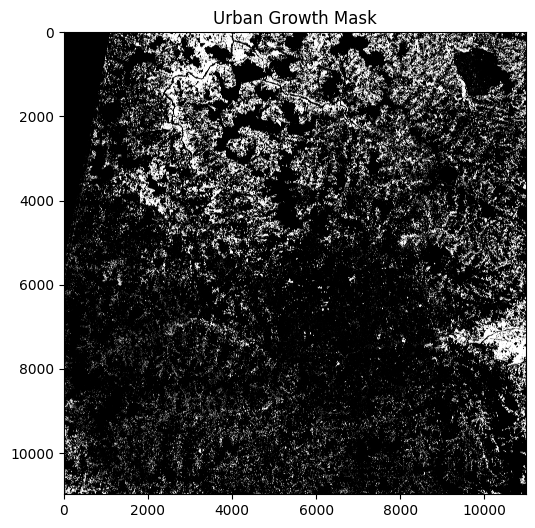

In [34]:
plt.figure(
    figsize=(8,6)
)

plt.imshow(
    urban_growth_mask,
    cmap="gray"
)

plt.title(
    "Urban Growth Mask"
)

plt.show()

In [35]:
def ndvi(
    red,
    nir
):

    red = red.astype(
        np.float32
    )

    nir = nir.astype(
        np.float32
    )

    return (
        (nir - red)
        /
        (nir + red + 1e-6)
    )

In [36]:
ndvi_2021 = ndvi(
    red_2021,
    nir_2021
)

ndvi_2026 = ndvi(
    red_2026,
    nir_2026
)

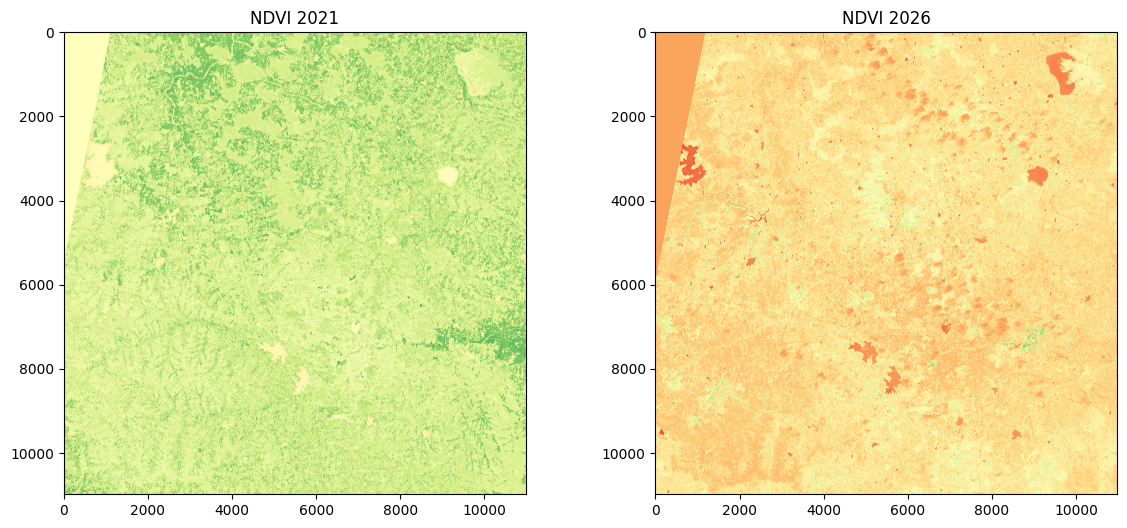

In [37]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

ax[0].imshow(
    ndvi_2021,
    cmap="RdYlGn"
)

ax[0].set_title(
    "NDVI 2021"
)

ax[1].imshow(
    ndvi_2026,
    cmap="RdYlGn"
)

ax[1].set_title(
    "NDVI 2026"
)

plt.show()

In [38]:
ndvi_change = (
    ndvi_2026
    -
    ndvi_2021
)

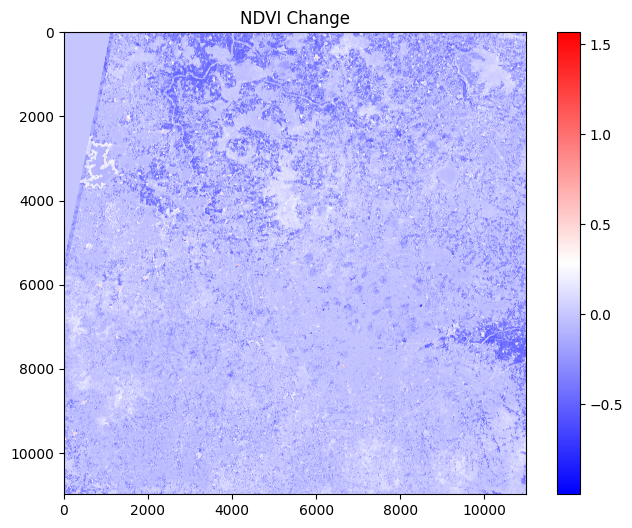

In [39]:
plt.figure(
    figsize=(8,6)
)

plt.imshow(
    ndvi_change,
    cmap="bwr"
)

plt.colorbar()

plt.title(
    "NDVI Change"
)

plt.show()

In [40]:
vegetation_loss_mask = (
    ndvi_change < -0.20
).astype(
    np.uint8
)

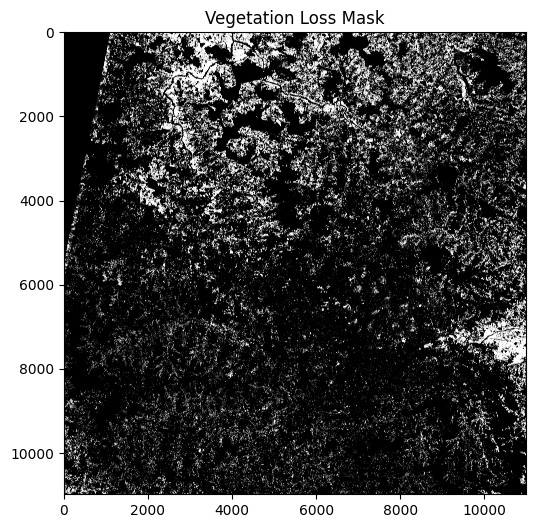

In [41]:
plt.figure(
    figsize=(8,6)
)

plt.imshow(
    vegetation_loss_mask,
    cmap="gray"
)

plt.title(
    "Vegetation Loss Mask"
)

plt.show()

In [42]:
change_map = np.zeros(
    vegetation_loss_mask.shape,
    dtype=np.uint8
)

change_map[
    vegetation_loss_mask == 1
] = 1

change_map[
    urban_growth_mask == 1
] = 2

In [43]:
change_map = np.zeros(
    vegetation_loss_mask.shape,
    dtype=np.uint8
)

change_map[
    vegetation_loss_mask == 1
] = 1

change_map[
    urban_growth_mask == 1
] = 2

In [44]:
def save_tif(
    reference_path,
    array,
    output_path
):

    with rasterio.open(
        reference_path
    ) as src:

        profile = src.profile

    profile.update(
        dtype=rasterio.float32,
        count=1,
        driver="GTiff"
    )

    with rasterio.open(
        output_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            array.astype(
                np.float32
            ),
            1
        )

In [45]:
reference = paths_2021["B04"]

save_tif(
    reference,
    ndvi_2021,
    output_dir / "ndvi_2021.tif"
)

save_tif(
    reference,
    ndvi_2026,
    output_dir / "ndvi_2026.tif"
)

save_tif(
    reference,
    ndvi_change,
    output_dir / "ndvi_change.tif"
)

save_tif(
    reference,
    ndbi_2021,
    output_dir / "ndbi_2021.tif"
)

save_tif(
    reference,
    ndbi_2026,
    output_dir / "ndbi_2026.tif"
)

save_tif(
    reference,
    ndbi_change,
    output_dir / "ndbi_change.tif"
)

save_tif(
    reference,
    vegetation_loss_mask,
    output_dir / "vegetation_loss_mask.tif"
)

save_tif(
    reference,
    urban_growth_mask,
    output_dir / "urban_growth_mask.tif"
)

save_tif(
    reference,
    change_map,
    output_dir / "geosentinel_change_map.tif"
)

print(
    "All outputs saved successfully."
)

All outputs saved successfully.
